# County-Level OHCA GWR with SVI Risk Factors (Georgia)

This notebook estimates spatially varying associations between county OHCA case counts and selected Social Vulnerability Index (SVI) variables using **Geographically Weighted Regression (GWR)**.

## Risk factors used
- `EP_AGE65`:% aged 65 and older. Older adults have much higher cardiac arrest risk.
- `EP_DISABL`:% civilian population with disability. Captures health vulnerability and chronic disease burden indirectly.
- `EP_UNINSUR`:% uninsured. Related to poorer healthcare access and delayed treatment/prevention.
- `EP_POV150`: % below 150% poverty. Poverty is strongly related to health risk, chronic disease, and emergency outcomes
- `EP_NOHSDP`:% age 25+ with no high school diploma. Education reflects socioeconomic status and health literacy.
- `EP_UNEMP`: Unemployment rate. Captures economic disadvantage and neighborhood-level health vulnerability.
- `EP_NOVEH`: % households with no vehicle. Related to healthcare access, EMS dependence, and transportation disadvantage.
- `EP_MINRTY`:% racial/ethnic minority population. Important for capturing structural inequities and spatial disparities in OHCA risk.

## 1. Install Packages

In [1]:
!pip -q install geopandas mgwr matplotlib mapclassify

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## 2. Imports and Paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR

LOCAL_ROOT = Path('/Users/jenny/Desktop/Workshop/')
COLAB_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/Workshop/')
ROOT = COLAB_ROOT if COLAB_ROOT.exists() else LOCAL_ROOT

DATA_DIR = ROOT/'data'

OHCA_CSV = DATA_DIR/'ohca_connected_data.csv'
COUNTY_SHP = DATA_DIR/'cb_2018_us_county_500k'/'cb_2018_us_county_500k - Copy.shp'
SVI_CSV = ROOT/'data'/'svi_GA_county.csv'


print('OHCA:', OHCA_CSV)
print('County shapefile:', COUNTY_SHP)
print('SVI:', SVI_CSV)


OHCA: /Users/jenny/Desktop/Workshop/data/ohca_connected_data.csv
County shapefile: /Users/jenny/Desktop/Workshop/data/cb_2018_us_county_500k/cb_2018_us_county_500k - Copy.shp
SVI: /Users/jenny/Desktop/Workshop/data/svi_GA_county.csv


## 3. Build County OHCA Case Counts

In [2]:

lat_col = 'scene_gps_latitude_escene.11'
lon_col = 'scene_gps_longitude_escene.11'

ohca = pd.read_csv(OHCA_CSV)
ohca[lat_col] = pd.to_numeric(ohca[lat_col], errors='coerce')
ohca[lon_col] = pd.to_numeric(ohca[lon_col], errors='coerce')
ohca = ohca.dropna(subset=[lat_col, lon_col]).copy()

ohca_points = gpd.GeoDataFrame(
    ohca,
    geometry=gpd.points_from_xy(ohca[lon_col], ohca[lat_col]),
    crs='EPSG:4326'
)

counties = gpd.read_file(COUNTY_SHP).to_crs('EPSG:4326')
ga_counties = counties[counties['STATEFP'].astype(str) == '13'][['GEOID', 'NAME', 'geometry']].copy()

joined = gpd.sjoin(
    ohca_points,
    ga_counties,
    how='inner',
    predicate='within'
).drop(columns=['index_right'], errors='ignore')

ohca_county = (
    joined.groupby(['GEOID', 'NAME'])
    .size()
    .rename('ohca_cases')
    .reset_index()
)

ga_counties = ga_counties.merge(ohca_county, on=['GEOID', 'NAME'], how='left')
ga_counties['ohca_cases'] = ga_counties['ohca_cases'].fillna(0).astype(int)

print('Georgia counties:', len(ga_counties))
print('Total OHCA cases assigned:', ga_counties['ohca_cases'].sum())
ga_counties[['GEOID', 'NAME', 'ohca_cases']].head()

Georgia counties: 159
Total OHCA cases assigned: 5963


,GEOID,NAME,ohca_cases
0,13009,Baldwin,0
1,13027,Brooks,2
2,13103,Effingham,3
3,13121,Fulton,232
4,13141,Hancock,0


## 4. Load SVI and Keep Requested Variables

In [3]:
svi_vars = [
    'EP_AGE65',
    'EP_DISABL',
    'EP_UNINSUR',
    'EP_POV150',
    'EP_NOHSDP',
    'EP_UNEMP',
    'EP_NOVEH',
    'EP_MINRTY'
]

svi = pd.read_csv(SVI_CSV)

# County key in provided CSV is FIPS; ensure 5-digit string.
svi['GEOID'] = svi['FIPS'].astype(str).str.zfill(5)

needed_cols = ['GEOID', 'COUNTY'] + svi_vars
missing = [c for c in needed_cols if c not in svi.columns]
if missing:
    raise ValueError(f'Missing required SVI columns: {missing}')

svi_sub = svi[needed_cols].copy()
for c in svi_vars:
    svi_sub[c] = pd.to_numeric(svi_sub[c], errors='coerce')

print('SVI rows:', len(svi_sub))
svi_sub.head()

SVI rows: 159


,GEOID,COUNTY,EP_AGE65,EP_DISABL,EP_UNINSUR,EP_POV150,EP_NOHSDP,EP_UNEMP,EP_NOVEH,EP_MINRTY
0,13001,Appling,17.2,15.1,12.3,37.3,22.8,3.8,8.2,31.1
1,13003,Atkinson,12.9,15.3,20.9,44.9,32.3,6.4,5.0,44.2
2,13005,Bacon,15.6,19.2,19.1,39.3,17.6,4.3,7.7,26.8
3,13007,Baker,29.8,19.6,13.6,39.2,16.8,14.0,7.6,49.9
4,13009,Baldwin,15.9,16.5,11.7,31.9,13.5,7.4,6.3,47.8


## 5. Merge OHCA Counts + SVI at County Level

In [4]:
gwr_gdf = ga_counties.merge(svi_sub, on='GEOID', how='left')

# Keep rows with complete SVI values
gwr_gdf = gwr_gdf.dropna(subset=svi_vars).copy()

print('Counties with complete SVI + OHCA:', len(gwr_gdf))
gwr_gdf[['GEOID', 'NAME', 'ohca_cases'] + svi_vars[:3]].head()

Counties with complete SVI + OHCA: 159


,GEOID,NAME,ohca_cases,EP_AGE65,EP_DISABL,EP_UNINSUR
0,13009,Baldwin,0,15.9,16.5,11.7
1,13027,Brooks,2,19.1,14.7,15.4
2,13103,Effingham,3,11.7,10.7,9.3
3,13121,Fulton,232,11.7,10.0,10.1
4,13141,Hancock,0,22.9,16.1,12.6


## 6. Prepare Inputs for GWR

We use county centroids as coordinate locations and standardize predictors for comparability.

Dependent variable:
- `log1p(ohca_cases)` for more stable Gaussian GWR fitting.

In [5]:
# Project for planar coordinates (meters)
gwr_3857 = gwr_gdf.to_crs('EPSG:3857').copy()
cent = gwr_3857.geometry.centroid
coords = np.column_stack([cent.x.values, cent.y.values])

# Response (n x 1)
y = np.log1p(gwr_3857['ohca_cases'].values).reshape((-1, 1))

# Predictors (n x p), standardized
X_raw = gwr_3857[svi_vars].values.astype(float)
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

print('coords shape:', coords.shape)
print('y shape:', y.shape)
print('X shape:', X.shape)

coords shape: (159, 2)
y shape: (159, 1)
X shape: (159, 8)


## 7. Select Bandwidth and Fit GWR

In [6]:
# Adaptive bandwidth (nearest-neighbor style) is often stable for county data
bw_selector = Sel_BW(coords, y, X, fixed=False)
bw = bw_selector.search()

print('Optimal adaptive bandwidth:', bw)

gwr_model = GWR(coords, y, X, bw, fixed=False)
gwr_results = gwr_model.fit()

print(gwr_results.summary())

Optimal adaptive bandwidth: 81.0
Model type                                                         Gaussian
Number of observations:                                                 159
Number of covariates:                                                     9

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            317.976
Log-likelihood:                                                    -280.710
AIC:                                                                579.421
AICc:                                                               582.907
BIC:                                                               -442.360
R2:                                                                   0.377
Adj. R2:                                                              0.343

Variable                              Est.         SE  t(Est/SE)    p-value
---------------------------

## 8. Save Local Coefficients and Diagnostics

In [7]:
# gwr_results.params includes intercept in column 0, then predictors
gwr_3857['gwr_intercept'] = gwr_results.params[:, 0]
for idx, v in enumerate(svi_vars, start=1):
    gwr_3857[f'gwr_b_{v}'] = gwr_results.params[:, idx]

gwr_3857['gwr_local_R2'] = gwr_results.localR2

# Local t-values (same column order as params)
for idx, v in enumerate(svi_vars, start=1):
    gwr_3857[f'gwr_t_{v}'] = gwr_results.filter_tvals()[:, idx]

gwr_3857[['NAME', 'gwr_local_R2'] + [f'gwr_b_{v}' for v in svi_vars[:3]]].head()

,NAME,gwr_local_R2,gwr_b_EP_AGE65,gwr_b_EP_DISABL,gwr_b_EP_UNINSUR
0,Baldwin,0.669711,-0.937721,-0.655353,0.641908
1,Brooks,0.389015,-0.276682,-0.400953,-0.079230
2,Effingham,0.517399,-0.159489,-0.258577,0.416774
3,Fulton,0.738722,-0.472904,0.275598,-0.051513
4,Hancock,0.673560,-0.947067,-0.679652,0.627798


## 9. Map Local Coefficients (Example)

Below we map local coefficients for one variable; repeat for others as needed.

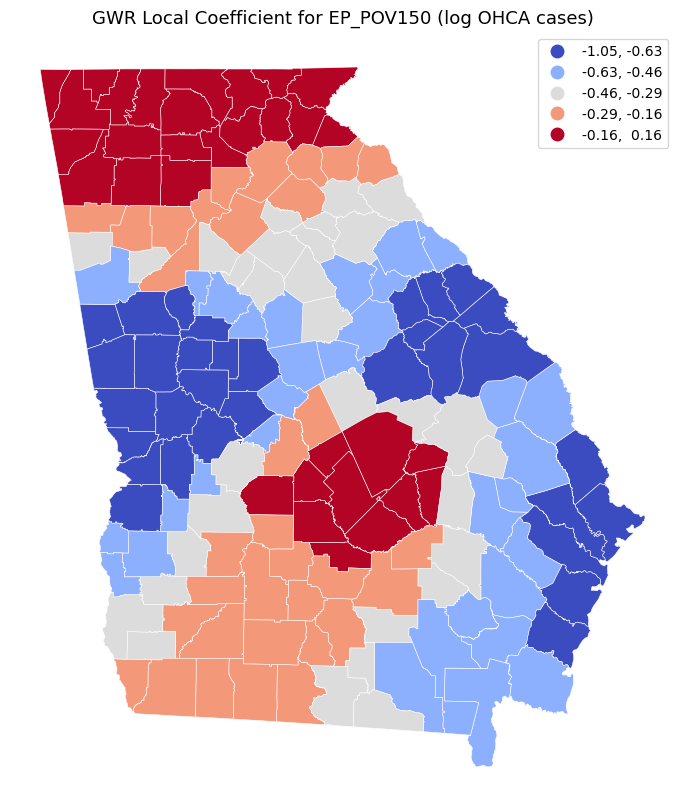

In [8]:
map_var = 'EP_POV150'  # change to any variable in svi_vars
coef_col = f'gwr_b_{map_var}'

gwr_plot = gwr_3857.to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 10))
gwr_plot.plot(
    column=coef_col,
    cmap='coolwarm',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax
)
ax.set_title(f'GWR Local Coefficient for {map_var} (log OHCA cases)', fontsize=13)
ax.axis('off')
plt.show()

## 10. Map Local R2

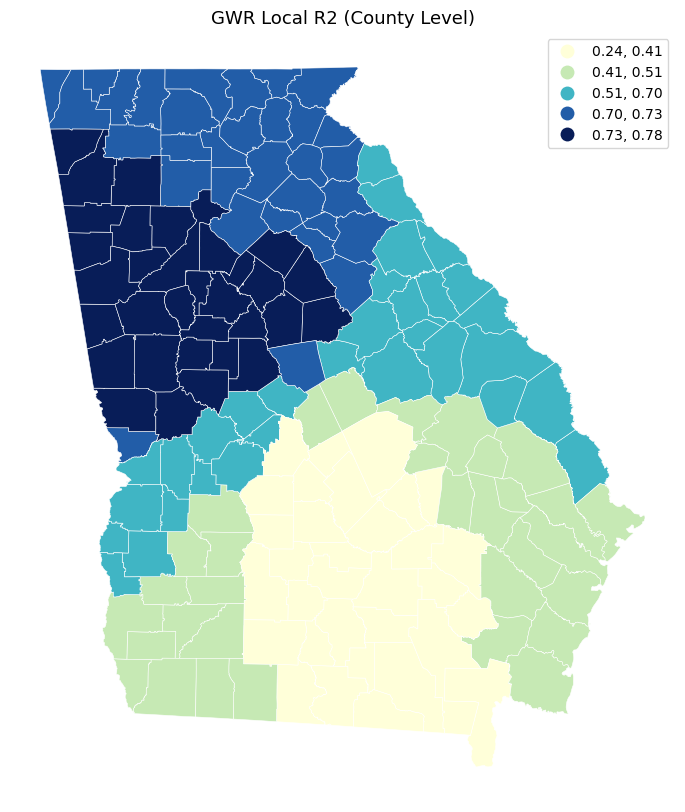

In [9]:
gwr_plot = gwr_3857.to_crs('EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 10))
gwr_plot.plot(
    column='gwr_local_R2',
    cmap='YlGnBu',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax
)
ax.set_title('GWR Local R2 (County Level)', fontsize=13)
ax.axis('off')
plt.show()

## 11. Export Results

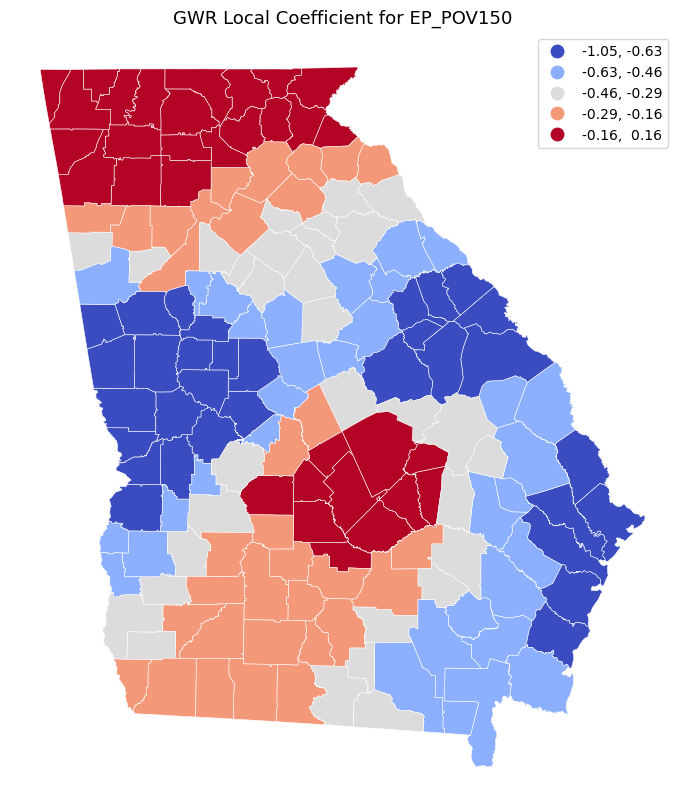

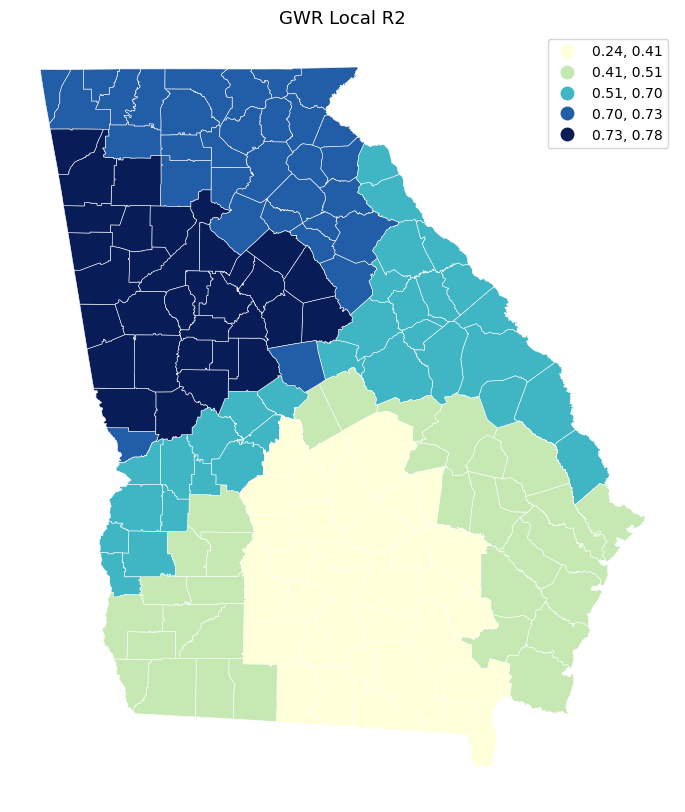

Saved CSV: /Users/jenny/Desktop/Workshop/data/outputs/county_ohca_gwr_svi_results.csv
Saved GeoJSON: /Users/jenny/Desktop/Workshop/data/outputs/county_ohca_gwr_svi_results.geojson
Saved coefficient map PNG: /Users/jenny/Desktop/Workshop/data/outputs/gwr_coef_EP_POV150_map.png
Saved local R2 map PNG: /Users/jenny/Desktop/Workshop/data/outputs/gwr_local_R2_map.png


In [10]:
OUTPUT_DIR = DATA_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

csv_out = OUTPUT_DIR / 'county_ohca_gwr_svi_results.csv'
geojson_out = OUTPUT_DIR / 'county_ohca_gwr_svi_results.geojson'
coef_map_png = OUTPUT_DIR / 'gwr_coef_EP_POV150_map.png'
r2_map_png = OUTPUT_DIR / 'gwr_local_R2_map.png'

gwr_out = gwr_3857.to_crs('EPSG:4326').copy()
gwr_out.drop(columns='geometry').to_csv(csv_out, index=False)
gwr_out.to_file(geojson_out, driver='GeoJSON')

# Save coefficient map
fig, ax = plt.subplots(figsize=(10, 10))
gwr_out.plot(
    column='gwr_b_EP_POV150',
    cmap='coolwarm',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax
)
ax.set_title('GWR Local Coefficient for EP_POV150', fontsize=13)
ax.axis('off')
fig.savefig(coef_map_png, dpi=300, bbox_inches='tight')
plt.show()

# Save local R2 map
fig, ax = plt.subplots(figsize=(10, 10))
gwr_out.plot(
    column='gwr_local_R2',
    cmap='YlGnBu',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax
)
ax.set_title('GWR Local R2', fontsize=13)
ax.axis('off')
fig.savefig(r2_map_png, dpi=300, bbox_inches='tight')
plt.show()

print('Saved CSV:', csv_out)
print('Saved GeoJSON:', geojson_out)
print('Saved coefficient map PNG:', coef_map_png)
print('Saved local R2 map PNG:', r2_map_png)

## Notes for Interpretation

- A positive local coefficient means higher predictor values are locally associated with higher log OHCA case counts.
- Coefficients can vary across counties; that is the key value of GWR.
- Compare local coefficient maps and local R2 to identify where model relationships are strongest.
- For inference-focused work, also consider count models, population offsets/rates, and multicollinearity diagnostics.